In [1]:
# ============================================================
# CELL 1: Install all required packages
# ============================================================
!pip install -q huggingface_hub gradio wandb
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'
print("✅ All packages installed")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 14.1 MB/s eta 0:00:00
✅ All packages installed


In [2]:
# ============================================================
# CELL 2: All Imports
# ============================================================
import os, json, copy, random, time, glob, shutil
from datetime import datetime
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import PIL

# Detectron2
import detectron2
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, DefaultPredictor, HookBase
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_train_loader
from detectron2.data import detection_utils as utils
from detectron2.data import transforms as T
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.utils.events import EventStorage
from detectron2.structures import BoxMode
from detectron2.data.transforms import TransformList
from detectron2.data import DatasetMapper
from detectron2.utils.logger import setup_logger
setup_logger()

# HuggingFace
from huggingface_hub import HfApi, login, create_repo, upload_folder
import gradio as gr

# WandB
import wandb

print("✅ All imports done")
print(f"🔥 CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🖥️  GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✅ All imports done
🔥 CUDA Available: True
🖥️  GPU: Tesla T4
💾 VRAM: 15.6 GB


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 3: All Paths and Config — EDIT THESE
# ============================================================

# --- Google Drive Paths ---
DRIVE_BASE     = "/content/drive/MyDrive"
DATASET_DIR    = f"{DRIVE_BASE}/HRSID_Dataset_COMPLETE"
OUTPUT_DIR     = f"{DRIVE_BASE}/HRSID_Training_Output"   # All checkpoints saved here
HF_CACHE_DIR   = f"{DRIVE_BASE}/HF_Model_Cache"

# --- HuggingFace Config ---
HF_TOKEN       = "api key"        # from huggingface.co/settings/tokens
HF_USERNAME    = "PUSHPENDAR"           # your HuggingFace username
HF_REPO_NAME   = "hrsid-ship-detection"       # repo name to create

# --- WandB Config (optional but recommended) ---
WANDB_API_KEY  = "api key"        # from wandb.ai/settings
WANDB_PROJECT  = "hrsid-faster-rcnn"
USE_WANDB      = True  # set False to skip

# --- Dataset Names (from your registration) ---
TRAIN_DATASET  = "HRSID_Train_113"
VAL_DATASET    = "HRSID_Val_113"
TEST_DATASET   = "HRSID_Test_113"

# --- Training Hyperparameters ---
MAX_ITER       = 5000     # Total iterations
CHECKPOINT_PERIOD = 500   # Save every N iterations
EVAL_PERIOD    = 500      # Evaluate every N iterations
BATCH_SIZE     = 2        # Images per batch (T4 GPU: keep at 2)
BASE_LR        = 0.00025  # Learning rate
NUM_CLASSES    = 1        # Ship = 1 class
SCORE_THRESH   = 0.5      # Confidence threshold for predictions

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(HF_CACHE_DIR, exist_ok=True)
print(f"✅ Output directory: {OUTPUT_DIR}")

✅ Output directory: /content/drive/MyDrive/HRSID_Training_Output


In [5]:
# Install JLclient
!pip install git+https://github.com/jarvislabsai/jlclient.git

  Cloning https://github.com/jarvislabsai/jlclient.git to /tmp/pip-req-build-1wgxbvhv
  Running command git clone --filter=blob:none --quiet https://github.com/jarvislabsai/jlclient.git /tmp/pip-req-build-1wgxbvhv
  Resolved https://github.com/jarvislabsai/jlclient.git to commit 48d02ddbb10c5113cc783ca0c5dc8ec45f99dcb3
  Preparing metadata (setup.py) ... done
  Created wheel for jlclient: filename=jlclient-0.1-py3-none-any.whl size=5463 sha256=b1d9b85d9c843a986929e4ab18bb31546820253c275ecf48e8bb9a34d9c3ffed
  Stored in directory: /tmp/pip-ephem-wheel-cache-k7ovdfar/wheels/55/17/df/406f8f1929c2244c87390a43adca082229bc0cd8ddd7acc7b5
Successfully built jlclient


In [6]:
# ============================================================
# CELL 4: Register Datasets (your existing working code)
# ============================================================

def register_COCO_datasets():
    SubFoldrs = sorted([f for f in os.listdir(DATASET_DIR)
                        if os.path.isdir(os.path.join(DATASET_DIR, f))])
    print(f"Found folders: {SubFoldrs}")

    dataset_names = []
    folder_map = {}
    for folder in SubFoldrs:
        ann_file  = os.path.join(DATASET_DIR, folder, "labels.json")
        img_dir   = os.path.join(DATASET_DIR, folder, "data")
        name      = f"HRSID_{folder.replace('_set','').capitalize()}_113"
        register_coco_instances(name, {}, ann_file, img_dir)
        MetadataCatalog.get(name).set(thing_classes=["ship"])
        dataset_names.append(name)
        folder_map[folder] = name
        print(f"  ✅ Registered: {name}")

    return dataset_names

# Register (skip if already registered)
try:
    dataset_names = register_COCO_datasets()
    print(f"\n✅ Datasets: {dataset_names}")
except Exception as e:
    print(f"Already registered or error: {e}")
    dataset_names = [TRAIN_DATASET, VAL_DATASET, TEST_DATASET]

# Verify counts
for name in dataset_names:
    try:
        count = len(DatasetCatalog.get(name))
        print(f"  📊 {name}: {count} images")
    except:
        pass

Found folders: ['test_set', 'train_set', 'val_set']
  ✅ Registered: HRSID_Test_113
  ✅ Registered: HRSID_Train_113
  ✅ Registered: HRSID_Val_113

✅ Datasets: ['HRSID_Test_113', 'HRSID_Train_113', 'HRSID_Val_113']
[02/17 17:29:39 d2.data.datasets.coco]: Loading /content/drive/MyDrive/HRSID_Dataset_COMPLETE/test_set/labels.json takes 2.07 seconds.
[02/17 17:29:39 d2.data.datasets.coco]: Loaded 5604 images in COCO format from /content/drive/MyDrive/HRSID_Dataset_COMPLETE/test_set/labels.json
  📊 HRSID_Test_113: 5604 images
[02/17 17:29:40 d2.data.datasets.coco]: Loaded 2914 images in COCO format from /content/drive/MyDrive/HRSID_Dataset_COMPLETE/train_set/labels.json
  📊 HRSID_Train_113: 2914 images
[02/17 17:29:40 d2.data.datasets.coco]: Loaded 728 images in COCO format from /content/drive/MyDrive/HRSID_Dataset_COMPLETE/val_set/labels.json
  📊 HRSID_Val_113: 728 images


In [7]:
# ============================================================
# CELL 5: Custom Data Mapper with Augmentation
# ============================================================

from detectron2.data.transforms import TransformList
from detectron2.data.detection_utils import transform_instance_annotations

def mapper(dataset_dict):
    dataset_dict = copy.deepcopy(dataset_dict)
    image = utils.read_image(dataset_dict["file_name"], format="BGR")

    auginput = T.AugInput(image)
    transform = T.Resize((1400, 1400), interp=PIL.Image.BILINEAR)(auginput)
    image = torch.from_numpy(copy.deepcopy(auginput.image.transpose(2, 0, 1)))

    annos = [
        transform_instance_annotations(annotation, [transform], image.shape[1:])
        for annotation in dataset_dict.pop("annotations")
        if annotation.get("iscrowd", 0) == 0
    ]

    instances = utils.annotations_to_instances(annos, image.shape[1:])
    dataset_dict["image"] = image
    dataset_dict["instances"] = utils.filter_empty_instances(instances)
    return dataset_dict

print("✅ Custom mapper defined")

✅ Custom mapper defined


In [8]:
# ============================================================
# CELL 6: WandB Logger Hook + Time Estimator
# ============================================================

class WandBHook(HookBase):
    """Logs training metrics to WandB after each iteration."""

    def after_step(self):
        storage = self.trainer.storage
        if USE_WANDB and storage.iter % 20 == 0:   # log every 20 iters
            metrics = {}
            for k, (v, _) in storage.latest().items():
                metrics[k] = v
            metrics["iteration"] = storage.iter
            try:
                wandb.log(metrics, step=storage.iter)
            except:
                pass


class TimeEstimatorHook(HookBase):
    """Prints ETA and speed every 100 iterations."""

    def __init__(self, max_iter, start_iter=0):
        self.max_iter   = max_iter
        self.start_iter = start_iter
        self.start_time = None

    def before_train(self):
        self.start_time = time.time()
        print(f"\n⏱️  Training started at {datetime.now().strftime('%H:%M:%S')}")
        remaining = self.max_iter - self.start_iter
        # T4 GPU rough estimate: ~1.2 sec/iter for HRSID 1400x1400 images
        est_sec = remaining * 1.2
        h, m = divmod(int(est_sec), 3600)
        m, s = divmod(m, 60)
        print(f"📊 Remaining iterations: {remaining}")
        print(f"⏳ Estimated time: {h}h {m}m {s}s  (≈{est_sec/3600:.1f} hrs)\n")

    def after_step(self):
        iteration = self.trainer.storage.iter
        if iteration % 100 == 0 and self.start_time is not None:
            elapsed  = time.time() - self.start_time
            done     = iteration - self.start_iter
            if done > 0:
                speed    = done / elapsed          # iters/sec
                remain   = self.max_iter - iteration
                eta_sec  = remain / speed
                h, m     = divmod(int(eta_sec), 3600)
                m, s     = divmod(m, 60)
                print(f"[Iter {iteration}/{self.max_iter}] "
                      f"Speed: {speed:.2f} it/s | "
                      f"ETA: {h}h {m}m {s}s")

print("✅ Hooks defined")

✅ Hooks defined


In [9]:
# ============================================================
# CELL 7: Custom Trainer — Auto-Resume + Checkpointing
# ============================================================

class HRSIDTrainer(DefaultTrainer):
    """
    Custom Detectron2 Trainer:
    - Uses custom mapper (augmentation + resize)
    - COCO evaluation on validation set
    - Hooks: WandB logging, time estimator
    """

    @classmethod
    def build_train_loader(cls, cfg):
        return build_detection_train_loader(cfg, mapper=mapper)

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "eval")
        os.makedirs(output_folder, exist_ok=True)
        return COCOEvaluator(dataset_name, cfg, False, output_dir=output_folder)

    def build_hooks(self):
        hooks = super().build_hooks()
        # Find what iteration we're resuming from
        start_iter = self.start_iter if hasattr(self, 'start_iter') else 0
        hooks.append(WandBHook())
        hooks.append(TimeEstimatorHook(
            max_iter=self.cfg.SOLVER.MAX_ITER,
            start_iter=start_iter
        ))
        return hooks


def find_last_checkpoint(output_dir):
    """Returns path to last checkpoint if exists, else None."""
    last_ckpt = os.path.join(output_dir, "last_checkpoint")
    if os.path.exists(last_ckpt):
        with open(last_ckpt) as f:
            ckpt_name = f.read().strip()
        ckpt_path = os.path.join(output_dir, ckpt_name)
        if os.path.exists(ckpt_path):
            print(f"🔄 Found checkpoint: {ckpt_name}")
            return ckpt_path
    return None


def build_cfg(resume=True):
    """Build and return Detectron2 config."""
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(
        "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
    ))

    # Datasets
    cfg.DATASETS.TRAIN = (TRAIN_DATASET,)
    cfg.DATASETS.TEST  = (VAL_DATASET,)

    # DataLoader
    cfg.DATALOADER.NUM_WORKERS = 2

    # Model weights
    last_ckpt = find_last_checkpoint(OUTPUT_DIR)
    if resume and last_ckpt:
        cfg.MODEL.WEIGHTS = last_ckpt
        print(f"✅ Resuming from: {last_ckpt}")
    else:
        cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
            "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
        )
        print("🆕 Starting fresh from COCO pretrained weights")

    cfg.MODEL.ROI_HEADS.NUM_CLASSES   = NUM_CLASSES
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = SCORE_THRESH

    # Solver
    cfg.SOLVER.IMS_PER_BATCH          = BATCH_SIZE
    cfg.SOLVER.BASE_LR                = BASE_LR
    cfg.SOLVER.MAX_ITER               = MAX_ITER
    cfg.SOLVER.STEPS                  = (int(MAX_ITER * 0.7), int(MAX_ITER * 0.9))  # LR decay
    cfg.SOLVER.GAMMA                  = 0.1
    cfg.SOLVER.WARMUP_ITERS           = 200
    cfg.SOLVER.CHECKPOINT_PERIOD      = CHECKPOINT_PERIOD  # Save every N iters

    # Evaluation
    cfg.TEST.EVAL_PERIOD               = EVAL_PERIOD
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128

    # Output
    cfg.OUTPUT_DIR = OUTPUT_DIR

    return cfg

print("✅ Trainer class and config builder ready")

✅ Trainer class and config builder ready


In [10]:
# ============================================================
# CELL 8: START / RESUME TRAINING  ← RUN THIS EACH SESSION
# ============================================================

# --- WandB Init ---
if USE_WANDB:
    try:
        wandb.login(key=WANDB_API_KEY)
        wandb.init(
            project=WANDB_PROJECT,
            name=f"hrsid-run-{datetime.now().strftime('%m%d-%H%M')}",
            resume="allow",  # continues existing run if possible
            config={
                "max_iter": MAX_ITER,
                "batch_size": BATCH_SIZE,
                "lr": BASE_LR,
                "num_classes": NUM_CLASSES,
                "dataset": "HRSID",
                "model": "Faster-RCNN-R50-FPN"
            }
        )
        print("✅ WandB initialized")
    except Exception as e:
        print(f"⚠️  WandB failed (continuing without): {e}")
        USE_WANDB = False

# --- Build Config ---
cfg = build_cfg(resume=True)   # Auto-detects checkpoint

# --- Check what iteration we're at ---
last_ckpt = find_last_checkpoint(OUTPUT_DIR)
if last_ckpt:
    # Parse iteration number from filename like model_0001000.pth
    import re
    match = re.search(r'(\d+)', os.path.basename(last_ckpt))
    current_iter = int(match.group(1)) if match else 0
    remaining = MAX_ITER - current_iter
    print(f"\n📍 Resuming from iteration: {current_iter}")
    print(f"📊 Iterations remaining: {remaining}")
    est_hrs = (remaining * 1.2) / 3600
    print(f"⏳ Estimated time to finish: {est_hrs:.1f} hours")
else:
    print(f"\n🆕 Fresh training: {MAX_ITER} iterations")
    print(f"⏳ Estimated total time: {(MAX_ITER * 1.2)/3600:.1f} hours")

print(f"\n💾 All checkpoints → {OUTPUT_DIR}")
print("─" * 50)

# --- Train ---
trainer = HRSIDTrainer(cfg)
trainer.resume_or_load(resume=True)   # KEY LINE: resumes if checkpoint exists
trainer.train()

print("\n🎉 Training complete!")
if USE_WANDB:
    wandb.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: pushpendarchoudhary106 (pushpendarchoudhary106-vesit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, mcp] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


✅ WandB initialized
🆕 Starting fresh from COCO pretrained weights

🆕 Fresh training: 5000 iterations
⏳ Estimated total time: 1.7 hours

💾 All checkpoints → /content/drive/MyDrive/HRSID_Training_Output
──────────────────────────────────────────────────
[02/17 17:29:44 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxP

model_final_280758.pkl: 167MB [00:00, 211MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[02/17 17:29:46 d2.engine.train_loop]: Starting training from iteration 0

⏱️  Training started at 17:29:46
📊 Remaining iterations: 5000
⏳ Estimated time: 1h 40m 0s  (≈1.7 hrs)



/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0217 17:29:59.848000 944 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[02/17 17:30:17 d2.utils.events]:  eta: 1:12:15  iter: 19  total_loss: 1.18  loss_cls: 0.6621  loss_box_reg: 0.3927  loss_rpn_cls: 0.05645  loss_rpn_loc: 0.009542    time: 0.8711  last_time: 0.8692  data_time: 0.5425  last_data_time: 0.0074   lr: 2.3976e-05  max_mem: 4520M
[02/17 17:30:41 d2.utils.events]:  eta: 1:12:57  iter: 39  total_loss: 1.025  loss_cls: 0.4333  loss_box_reg: 0.4544  loss_rpn_cls: 0.03773  loss_rpn_loc: 0.01771    time: 0.8853  last_time: 0.8905  data_time: 0.0074  last_data_time: 0.0059   lr: 4.8951e-05  max_mem: 4520M
[02/17 17:31:00 d2.utils.events]:  eta: 1:13:18  iter: 59  total_loss: 1.017  loss_cls: 0.3506  loss_box_reg: 0.6039  loss_rpn_cls: 0.006048  loss_rpn_loc: 0.00855    time: 0.9047  last_time: 0.9391  data_time: 0.0073  last_data_time: 0.0074   lr: 7.3926e-05  max_mem: 4520M
[02/17 17:31:19 d2.utils.events]:  eta: 1:14:49  iter: 79  total_loss: 0.9575  loss_cls: 0.3278  loss_box_reg: 0.6298  loss_rpn_cls: 0.004307  loss_rpn_loc: 0.006915    time: 0.

bbox/AP,▁▁▁▄▄▄▄▅▅▅▅▅▅▅▅▄▄▄▄▄█████▅▅▅▅▅▇▇▇▇▇▇▇▇▇▇
bbox/AP50,▁▁▁▁▁▁▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆█████▇▇▇▇▇▇▇▇▇▇
bbox/AP75,▁▁▁▁▁▅▅▅▅▅▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▅█████▅▅▅▇▇▇▇▇▇
bbox/APl,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▇▇▇▇▇▆▆▆▅▅▅▅▅▆▆▆▆███▆▆▆▆▆
bbox/APm,▁▁▁▁▁▄▄▄▄▄▄▄▄▆▆▆▃▃▃▃▃▃▃▃████▄▄▄▄▄▇▇▇▇▇▇▇
bbox/APs,▁▁▁▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄███▅▅▅▅▆▆▇▇▇▇
data_time,▁▁▃▁▂▁▄▂▁▄▄▂▂▃▂▁▃▂▅▇█▂█▆▃▂▂▁▂▂▃▆▁▃▃▃▃▂▅▂
eta_seconds,▇▇███▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
fast_rcnn/cls_accuracy,█▇▅▄▆█▁▄▇██▆▇▅▇▇▇▇█▇▅▇██▇▅█▇▇███▇▇█▇███▇
fast_rcnn/false_negative,▃▇▁▁▁▂▁▃▂▁▁▁▁▁▁▅▁▂▁▁█▆▃▁▁▁▁▁▁▁▁▃▁▁▁▁▁▁▅▂
+14,...


In [11]:
# ============================================================
# CELL 9: Final Evaluation on Test Set
# ============================================================

# Load best/final model
cfg_eval = build_cfg(resume=True)
cfg_eval.MODEL.WEIGHTS = os.path.join(OUTPUT_DIR, "model_final.pth")
cfg_eval.MODEL.ROI_HEADS.SCORE_THRESH_TEST = SCORE_THRESH
cfg_eval.DATASETS.TEST = (TEST_DATASET,)

predictor = DefaultPredictor(cfg_eval)

# Run COCO evaluation
print("📊 Running COCO evaluation on test set...")
evaluator  = COCOEvaluator(TEST_DATASET, cfg_eval, False,
                            output_dir=os.path.join(OUTPUT_DIR, "test_eval"))
test_loader = build_detection_test_loader(cfg_eval, TEST_DATASET)
results = inference_on_dataset(predictor.model, test_loader, evaluator)

print("\n" + "="*50)
print("📈 TEST SET RESULTS")
print("="*50)
for metric, value in results.get("bbox", {}).items():
    print(f"  {metric:35s}: {value:.4f}")

🔄 Found checkpoint: model_final.pth
✅ Resuming from: /content/drive/MyDrive/HRSID_Training_Output/model_final.pth
[02/17 19:13:35 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/HRSID_Training_Output/model_final.pth ...
📊 Running COCO evaluation on test set...
WARNING [02/17 19:13:35 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
[02/17 19:13:38 d2.data.datasets.coco]: Loading /content/drive/MyDrive/HRSID_Dataset_COMPLETE/test_set/labels.json takes 1.25 seconds.
[02/17 19:13:38 d2.data.datasets.coco]: Loaded 5604 images in COCO format from /content/drive/MyDrive/HRSID_Dataset_COMPLETE/test_set/labels.json
[02/17 19:13:38 d2.data.build]: Distribution of instances among all 1 categories:
|  category  | #instances   |
|:----------:|:-------------|
|    ship    | 16951        |
|            |              |
[02/17 19:13:38 d2.data.dataset_mappe

[02/17 19:28:53 d2.data.datasets.coco]: Loaded 5604 images in COCO format from /content/drive/MyDrive/HRSID_Dataset_COMPLETE/test_set/labels.json


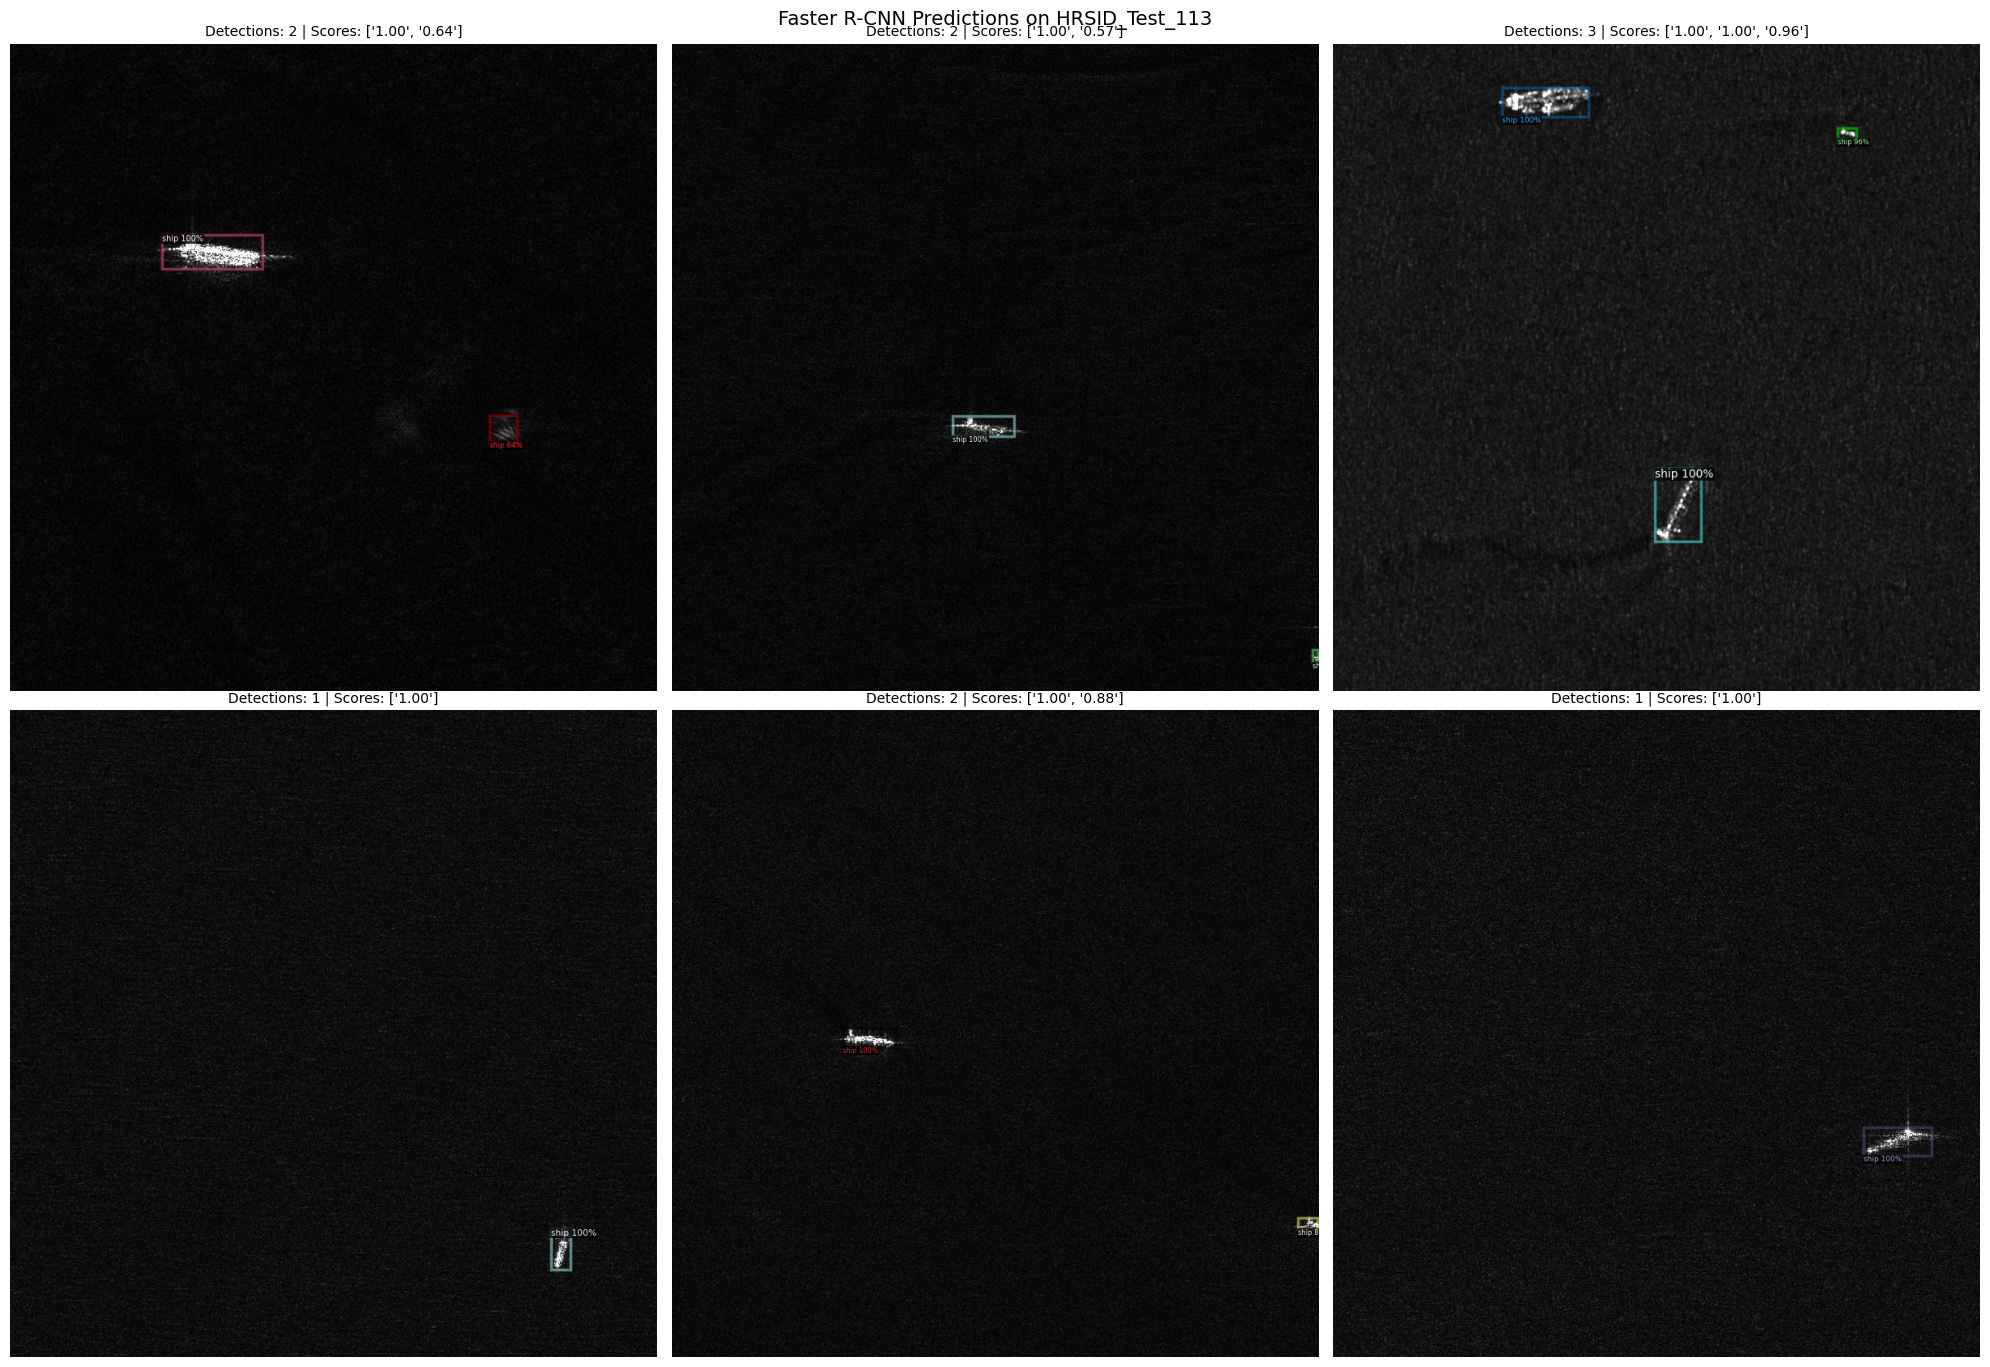

✅ Predictions saved to: /content/drive/MyDrive/HRSID_Training_Output/predictions_sample.png


In [12]:
# ============================================================
# CELL 10: Visual Predictions on Test Images
# ============================================================

def show_predictions(predictor, dataset_name, num_images=6, score_thresh=0.5):
    """Display predictions on random test images."""
    dataset_dicts = DatasetCatalog.get(dataset_name)
    metadata      = MetadataCatalog.get(dataset_name)
    samples       = random.sample(dataset_dicts, min(num_images, len(dataset_dicts)))

    fig, axes = plt.subplots(2, 3, figsize=(20, 14))
    axes = axes.flatten()

    for idx, d in enumerate(samples):
        img = cv2.imread(d["file_name"])
        outputs = predictor(img)

        v = Visualizer(img[:, :, ::-1], metadata=metadata,
                       scale=1.0, instance_mode=ColorMode.IMAGE)
        out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

        num_det = len(outputs["instances"])
        scores  = outputs["instances"].scores.tolist() if num_det > 0 else []

        axes[idx].imshow(out.get_image())
        axes[idx].set_title(
            f"Detections: {num_det} | "
            f"Scores: {[f'{s:.2f}' for s in scores[:3]]}",
            fontsize=10
        )
        axes[idx].axis("off")

    plt.suptitle(f"Faster R-CNN Predictions on {dataset_name}", fontsize=14)
    plt.tight_layout()

    # Save figure
    save_path = os.path.join(OUTPUT_DIR, "predictions_sample.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Predictions saved to: {save_path}")


show_predictions(predictor, TEST_DATASET, num_images=6)

In [14]:
# ============================================================
# CELL 11: Prepare Model Package for HuggingFace
# ============================================================

HF_EXPORT_DIR = os.path.join(HF_CACHE_DIR, HF_REPO_NAME)
os.makedirs(HF_EXPORT_DIR, exist_ok=True)

# 1. Copy model weights
shutil.copy(
    os.path.join(OUTPUT_DIR, "model_final.pth"),
    os.path.join(HF_EXPORT_DIR, "model_final.pth")
)

# 2. Save config as YAML
with open(os.path.join(HF_EXPORT_DIR, "config.yaml"), "w") as f:
    f.write(cfg_eval.dump())

# 3. Save class labels
with open(os.path.join(HF_EXPORT_DIR, "labels.json"), "w") as f:
    json.dump({"0": "ship", "thing_classes": ["ship"]}, f)

# 4. Save model card (README.md)
model_card = f"""---
license: apache-2.0
tags:
  - object-detection
  - detectron2
  - ship-detection
  - SAR
  - faster-rcnn
datasets:
  - HRSID
---

# 🚢 HRSID Ship Detection — Faster R-CNN

Ship detection model trained on the **HRSID (High-Resolution SAR Images Dataset)**
using **Faster R-CNN with ResNet-50 FPN** backbone via Detectron2.

## Model Details
| Property | Value |
|---|
| Architecture | Faster R-CNN R50-FPN |
| Dataset | HRSID |
| Classes | 1 (ship) |
| Input Size | 1400×1400 |
| Training Iterations | {MAX_ITER} |
| Score Threshold | {SCORE_THRESH} |

## Files
- `model_final.pth` — trained model weights
- `config.yaml` — Detectron2 config
- `labels.json` — class labels
- `app.py` — Gradio demo app

## Usage
```python
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor

cfg = get_cfg()
cfg.merge_from_file("config.yaml")
cfg.MODEL.WEIGHTS = "model_final.pth"
predictor = DefaultPredictor(cfg)

import cv2
img = cv2.imread("your_image.jpg")
outputs = predictor(img)
```
"""

with open(os.path.join(HF_EXPORT_DIR, "README.md"), "w") as f:
    f.write(model_card)

print(f"✅ Model package prepared at: {HF_EXPORT_DIR}")
print(f"   Files: {os.listdir(HF_EXPORT_DIR)}")

✅ Model package prepared at: /content/drive/MyDrive/HF_Model_Cache/hrsid-ship-detection
   Files: ['model_final.pth', 'config.yaml', 'labels.json', 'README.md']


In [15]:
# ============================================================
# CELL 12: Create Gradio App for HuggingFace Spaces
# ============================================================

app_code = '''
import gradio as gr
import cv2
import numpy as np
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import os

# Load model
cfg = get_cfg()
cfg.merge_from_file("config.yaml")
cfg.MODEL.WEIGHTS = "model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cpu"   # HF Spaces free tier is CPU

MetadataCatalog.get("__unused").set(thing_classes=["ship"])
predictor = DefaultPredictor(cfg)

def detect_ships(image, confidence_threshold):
    """Run ship detection on uploaded image."""
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = confidence_threshold

    # Convert PIL → BGR numpy
    img_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    outputs = predictor(img_bgr)
    instances = outputs["instances"].to("cpu")

    # Filter by threshold
    keep = instances.scores >= confidence_threshold
    instances = instances[keep]

    metadata = MetadataCatalog.get("__unused")
    v = Visualizer(img_bgr[:, :, ::-1], metadata=metadata,
                   scale=1.0, instance_mode=ColorMode.IMAGE)
    out = v.draw_instance_predictions(instances)

    result_img = out.get_image()
    num_ships  = len(instances)
    scores     = instances.scores.tolist()
    info = f"Detected {num_ships} ship(s)\\n"
    if scores:
        info += "Confidence scores: " + ", ".join([f"{s:.2f}" for s in scores])

    return result_img, info

demo = gr.Interface(
    fn=detect_ships,
    inputs=[
        gr.Image(type="pil", label="Upload SAR Image"),
        gr.Slider(0.1, 0.9, value=0.5, step=0.05, label="Confidence Threshold")
    ],
    outputs=[
        gr.Image(type="numpy", label="Detection Result"),
        gr.Textbox(label="Detection Info")
    ],
    title="🚢 HRSID Ship Detection",
    description="Upload a SAR image to detect ships using Faster R-CNN trained on HRSID dataset.",
    examples=[]
)

if __name__ == "__main__":
    demo.launch()
'''

with open(os.path.join(HF_EXPORT_DIR, "app.py"), "w") as f:
    f.write(app_code)

# Requirements file for Spaces
requirements = """torch
torchvision
detectron2 @ git+https://github.com/facebookresearch/detectron2.git
gradio
opencv-python-headless
Pillow
"""
with open(os.path.join(HF_EXPORT_DIR, "requirements.txt"), "w") as f:
    f.write(requirements)

print("✅ Gradio app created")
print("✅ requirements.txt created")

✅ Gradio app created
✅ requirements.txt created


In [18]:
# ============================================================
# CELL 13: Upload to HuggingFace Hub
# ============================================================

print("🤗 Uploading to HuggingFace Hub...")

# Login
login(token=HF_TOKEN)
api = HfApi()

# Create model repo
repo_id = f"{HF_USERNAME}/{HF_REPO_NAME}"
try:
    create_repo(repo_id, token=HF_TOKEN, exist_ok=True, repo_type="model")
    print(f"✅ Model repo ready: {repo_id}")
except Exception as e:
    print(f"Repo already exists or error: {e}")

# Upload all model files
upload_folder(
    folder_path=HF_EXPORT_DIR,
    repo_id=repo_id,
    token=HF_TOKEN,
    repo_type="model",
    commit_message=f"Upload HRSID Faster-RCNN model trained for {MAX_ITER} iters"
)
print(f"✅ Model uploaded → https://huggingface.co/{repo_id}")

# Create Space repo for Gradio demo
space_repo_id = f"{HF_USERNAME}/{HF_REPO_NAME}-demo"
try:
    create_repo(space_repo_id, token=HF_TOKEN, exist_ok=True, repo_type="space",
                space_sdk="gradio")
    print(f"✅ Space repo ready: {space_repo_id}")
except Exception as e:
    print(f"Space already exists: {e}")

upload_folder(
    folder_path=HF_EXPORT_DIR,
    repo_id=space_repo_id,
    token=HF_TOKEN,
    repo_type="space",
    commit_message="Deploy HRSID ship detection Gradio app"
)

print(f"\n🎉 DEPLOYMENT COMPLETE!")
print(f"  📦 Model: https://huggingface.co/{repo_id}")
print(f"  🚀 Demo:  https://huggingface.co/spaces/{space_repo_id}")

🤗 Uploading to HuggingFace Hub...
✅ Model repo ready: PUSHPENDAR/hrsid-ship-detection


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...detection/model_final.pth:   0%|          | 36.5kB /  330MB            

✅ Model uploaded → https://huggingface.co/PUSHPENDAR/hrsid-ship-detection
✅ Space repo ready: PUSHPENDAR/hrsid-ship-detection-demo


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...detection/model_final.pth:   8%|7         | 25.1MB /  330MB            


🎉 DEPLOYMENT COMPLETE!
  📦 Model: https://huggingface.co/PUSHPENDAR/hrsid-ship-detection
  🚀 Demo:  https://huggingface.co/spaces/PUSHPENDAR/hrsid-ship-detection-demo
